# Classification
Next we use machine learning to predict loan risk using classification models. Those lose the magnitude of loss in a target, but possibly gain in signal.

In [1]:
import sys
sys.path.append('..')
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from src.data_load import load_data

df = load_data()
df = df[df.issue_d < '2018-01-01']

In [4]:
from sklearn.model_selection import train_test_split
from src.columns import FEATURE_COLS_CLEAN, REG_TARGET, CLASS_TARGET

df_train, df_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df[['is_default', 'issue_y']])

In [5]:
X_train = df_train[FEATURE_COLS_CLEAN]
X_test = df_test[FEATURE_COLS_CLEAN]
y_train = df_train[CLASS_TARGET[0]]
y_test = df_test[CLASS_TARGET[0]]

In [8]:
print(f"Defaults={df.is_default.sum()}")
print(f"Non-defaeults={(df.is_default == 0).sum()}")
print(f"Default % ={df.is_default.sum() / len(df.is_default)}")
print(f"Train size={len(df_train):e}")

Defaults=260483
Non-defaeults=1031267
Default % =0.20165124830656087
Train size=1.162575e+06


## LightGBM

Class imbalance is a common problem cited when training classification models. We have an imbalance of around 1 to 5 defaults to non-defaults, so it is not quite as severe. The most common pain point of class imbalance is connected to using accuracy as the ultimate measure of performance. This makes sense - in order for the model to work with a 50% threshold, it needs to be severely miscalibrated: it would have to artificially compress majority class probabilities below 0.5 and push minority class probabilities above 0.5, distorting the true underlying distribution. At the end of the day, accuracy is not a good measure of performance, especially when misclassification carries different consequences depending on the predicted class. We are using lift score, for which the only thing that matters is the correct ordering of probabilities, so that the self-discovered threshold point can maximize total return, making it less sensitive to class imbalance. ROC-AUC will also be used as a robust representation of model ranking ability.

The second problem with class imbalance is that some classification models implicitly assume class balance during training. In SVM, the hyperplane is pushed towards the minority class because the slack is dominated by the majority class. KNN ends up with the majority of neighbours belonging to the dominant class, resulting in skewed predictions. Increasing the weight of the minority class helps to combat this, but it skews predictions in the opposite direction, effectively undermining the geometric logic of these models.

The third problem concerns the representativeness of samples. The prior in Naive Bayes may not be representative of the underlying distribution due to low sample size. Splits in decision trees can end up with very few minority class observations, affecting both metrics and subsequent splits. Outside of these cases, decision trees seem to be quite robust to class imbalance, as long as the minority class is adequately represented.  We have a 20% minority class with 1.1M training records, yielding 220k defaults for $log_2 220000 = 17.47$ representative tree depth, which will experience overtraining long before, so we are somewhat safe. Tree-based models support class weighting, but it matters little in our case. It arguably only leads to a different bias-variance composition across classes - overfitting on the minority class at the expense of the majority - resulting in worse overall predictions, as observed when training LightGBM with class imbalance corrections during the devleopment of this notebook. Synthetic sampling of similar minority points is an option, but only with a clear understanding of the data and how much linear interpolation represents the real records. With complex signal structure, it can only hurt.

In [ ]:
import lightgbm as lgb

model = lgb.LGBMClassifier(n_estimators=1000)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)])

Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.470864
[20]	valid_0's binary_logloss: 0.461963
[30]	valid_0's binary_logloss: 0.457229
[40]	valid_0's binary_logloss: 0.454413
[50]	valid_0's binary_logloss: 0.4525
[60]	valid_0's binary_logloss: 0.451219
[70]	valid_0's binary_logloss: 0.450285
[80]	valid_0's binary_logloss: 0.449614
[90]	valid_0's binary_logloss: 0.449074
[100]	valid_0's binary_logloss: 0.448695
[110]	valid_0's binary_logloss: 0.44831
[120]	valid_0's binary_logloss: 0.448043
[130]	valid_0's binary_logloss: 0.447816
[140]	valid_0's binary_logloss: 0.447683
[150]	valid_0's binary_logloss: 0.447568
[160]	valid_0's binary_logloss: 0.447436
[170]	valid_0's binary_logloss: 0.447314
[180]	valid_0's binary_logloss: 0.447269
[190]	valid_0's binary_logloss: 0.447281
[200]	valid_0's binary_logloss: 0.447293
[210]	valid_0's binary_logloss: 0.447273
[220]	valid_0's binary_logloss: 0.447255
[230]	valid_0's binary_logloss: 0.447297
[240]	va

LGBMClassifier(n_estimators=1000)

Lift score can be used the same way as used for regression, as long as the probabilities represent the probability of not having a default and true returns are used as regression labels.

Threshold: 0.6815
Lift: 1.4804 times
Net improvement: $9.681129e+07 - $6.539672e+07 = $3.141457e+07


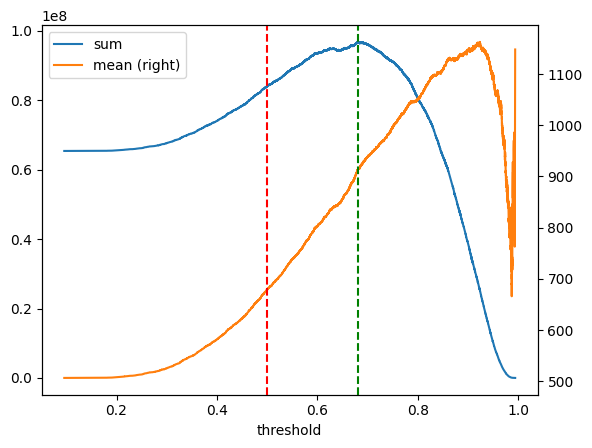

In [ ]:
from src.metrics import lift_score, build_curve, plot_curve
y_proba = model.predict_proba(X_test)[:, 0]
returns = df.loc[X_test.index, 'net_return']
plot_curve(build_curve(returns, y_proba), 0.5)

### LightGBM: model tuning
We use sampling the same way as we used in a regression task

In [27]:
df_sample = df_train.groupby(['is_default', 'issue_y']).sample(frac=0.1, random_state=42)
df_sample.shape

(116259, 120)

In [28]:
X_sample = df_sample[FEATURE_COLS_CLEAN]
y_sample = df_sample[CLASS_TARGET[0]]

There is no way to supply scorers with actual returns, so we have to manually implement K-fold cross-validation

In [ ]:
import lightgbm as lgb
import optuna
from sklearn.model_selection import KFold
import numpy as np

from src.metrics import lift_score


def objective(trial):
    params = {
        'objective': 'binary',
        'verbosity': -1,
        'learning_rate': 0.05,
        'subsample_freq': 1,
        'n_jobs': -1,

        'num_leaves': trial.suggest_int('num_leaves', 31, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_child_samples': trial.suggest_int('min_child_samples', 200, 3000),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 100.0, log=True),
    }
    
    model = lgb.LGBMClassifier(**params, n_estimators=1000, class_weight='balanced', random_state=42)


    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    lifts = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_sample)):
        X_fold_train, X_fold_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
        y_fold_train, y_fold_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]
        train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

        def eval_metric(y_true, y_score):
            return ('lift', lift_score(val_return, 1 - y_score), True)

        model.fit(
            X_fold_train, 
            y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)], 
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
            eval_metric=[eval_metric, 'binary_logloss'],
        )

        pred_proba = model.predict_proba(X_fold_val)[:, 0]

        lift = lift_score(val_return, pred_proba)
        lifts.append(lift)

    return np.mean(lifts)


study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-06-01 21:49:12,845] A new study created in memory with name: no-name-7d5957ae-5db6-41f5-86b4-17960ab9ac69


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.665141	valid_0's lift: 1.37719
[20]	valid_0's binary_logloss: 0.646939	valid_0's lift: 1.39983
[30]	valid_0's binary_logloss: 0.636968	valid_0's lift: 1.41763
[40]	valid_0's binary_logloss: 0.629719	valid_0's lift: 1.43639
[50]	valid_0's binary_logloss: 0.624359	valid_0's lift: 1.44836
[60]	valid_0's binary_logloss: 0.620141	valid_0's lift: 1.45822
[70]	valid_0's binary_logloss: 0.616729	valid_0's lift: 1.46762
[80]	valid_0's binary_logloss: 0.614131	valid_0's lift: 1.47353
[90]	valid_0's binary_logloss: 0.611824	valid_0's lift: 1.48445
[100]	valid_0's binary_logloss: 0.610105	valid_0's lift: 1.49453
[110]	valid_0's binary_logloss: 0.608426	valid_0's lift: 1.50623
[120]	valid_0's binary_logloss: 0.606954	valid_0's lift: 1.51571
[130]	valid_0's binary_logloss: 0.605758	valid_0's lift: 1.52871
[140]	valid_0's binary_logloss: 0.604439	valid_0's lift: 1.52916
[150]	valid_0's binary_logloss: 0.6033

It already looks like the model is worse than regression. Honestly, not incroporating information on magnitude of error seems to not allow to get better returns. Still, we might get a single decision tree of a good interpretability

In [55]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
89,89,1.538223,2026-05-30 17:17:23.078913,2026-05-30 17:18:36.467985,0 days 00:01:13.389072,0.411180,8,2620,0.004099,135,9.133390e-02,2.143140,0.745227,COMPLETE
97,97,1.535600,2026-05-30 17:24:19.629998,2026-05-30 17:25:22.917740,0 days 00:01:03.287742,0.481639,7,2775,0.001331,120,3.047278e-02,3.717407,0.734196,COMPLETE
8,8,1.534431,2026-05-30 16:12:17.091486,2026-05-30 16:13:03.002696,0 days 00:00:45.911210,0.527539,14,2743,0.464303,116,3.571720e+00,0.171571,0.692490,COMPLETE
72,72,1.533938,2026-05-30 17:02:13.694983,2026-05-30 17:03:03.958898,0 days 00:00:50.263915,0.607151,25,2941,0.001446,167,5.347962e-07,0.136951,0.856461,COMPLETE
20,20,1.533635,2026-05-30 16:19:19.711843,2026-05-30 16:20:02.941691,0 days 00:00:43.229848,0.598514,13,2984,1.050362,117,1.592717e+00,0.203774,0.809722,COMPLETE
31,31,1.533622,2026-05-30 16:26:00.012991,2026-05-30 16:26:44.811305,0 days 00:00:44.798314,0.516277,18,2813,0.019460,151,5.165545e-02,0.015564,0.659388,COMPLETE
39,39,1.533106,2026-05-30 16:33:05.102673,2026-05-30 16:34:06.460942,0 days 00:01:01.358269,0.594636,10,2979,0.031467,92,3.831315e+00,31.817487,0.781536,COMPLETE
99,99,1.532499,2026-05-30 17:25:51.180776,2026-05-30 17:27:02.680829,0 days 00:01:11.500053,0.483837,7,2884,0.003696,122,2.916825e-02,1.173231,0.721360,COMPLETE
50,50,1.530855,2026-05-30 16:42:39.475935,2026-05-30 16:43:35.601046,0 days 00:00:56.125111,0.448438,11,2442,0.398112,131,2.788265e-02,0.010240,0.662320,COMPLETE
60,60,1.530653,2026-05-30 16:50:47.003526,2026-05-30 16:51:52.838361,0 days 00:01:05.834835,0.501161,13,2540,1.052040,109,1.009643e-01,1.059239,0.783256,COMPLETE


Top parameterse are similar in lift score but different in parameters, so we are in a flat part of a search surface. Still we will need to conduct search on the whole train set.

In [57]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(6).filter(regex='^params_').agg(['min', 'max', 'mean'])

,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
min,0.411180,7.000000,2620.000000,0.001331,116.000000,5.347962e-07,0.015564,0.659388
max,0.607151,25.000000,2984.000000,1.050362,167.000000,3.571720e+00,3.717407,0.856461
mean,0.523717,14.166667,2812.666667,0.256834,134.333333,8.896499e-01,1.064734,0.749581


In [59]:
import lightgbm as lgb
import optuna
from sklearn.model_selection import KFold
import numpy as np

from src.metrics import lift_score


def objective(trial):
    params = {
        'objective': 'binary',
        'verbosity': -1,
        'learning_rate': 0.2,
        'subsample_freq': 1,
        'n_jobs': -1,

        'num_leaves': trial.suggest_int('num_leaves', 100, 180),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_child_samples': trial.suggest_int('min_child_samples', 2500, 3200),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 2.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 5e-7, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 5.0, log=True),
    }
    
    model = lgb.LGBMClassifier(**params, n_estimators=1000)


    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    lifts = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

        def eval_metric(y_true, y_score):
            return ('lift', lift_score(val_return, 1 - y_score), True)

        model.fit(
            X_fold_train, 
            y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)], 
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
            eval_metric=[eval_metric, 'binary_logloss'],
        )

        pred_proba = model.predict_proba(X_fold_val)[:, 0]

        lift = lift_score(val_return, pred_proba)
        lifts.append(lift)

    return np.mean(lifts)


study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-05-30 17:41:28,083] A new study created in memory with name: no-name-7b147ff4-2658-495c-8dab-f2ae33496145


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.455739	valid_0's lift: 1.39472
[20]	valid_0's binary_logloss: 0.449242	valid_0's lift: 1.45904
[30]	valid_0's binary_logloss: 0.447384	valid_0's lift: 1.4908
[40]	valid_0's binary_logloss: 0.446579	valid_0's lift: 1.5027
[50]	valid_0's binary_logloss: 0.446304	valid_0's lift: 1.51231
[60]	valid_0's binary_logloss: 0.44641	valid_0's lift: 1.51262
[70]	valid_0's binary_logloss: 0.446454	valid_0's lift: 1.51306
[80]	valid_0's binary_logloss: 0.446515	valid_0's lift: 1.51515
[90]	valid_0's binary_logloss: 0.446736	valid_0's lift: 1.51393
[100]	valid_0's binary_logloss: 0.44669	valid_0's lift: 1.51201
Early stopping, best iteration is:
[50]	valid_0's binary_logloss: 0.446304	valid_0's lift: 1.51231
Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.456281	valid_0's lift: 1.41305
[20]	valid_0's binary_logloss: 0.450289	valid_0's lift: 1.47885
[30]	valid_0's

In [60]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
23,23,1.551781,2026-05-30 19:34:23.132553,2026-05-30 19:40:57.441227,0 days 00:06:34.308674,0.548946,7,2885,1.654352,126,0.001791,0.812988,0.859773,COMPLETE
14,14,1.551074,2026-05-30 18:49:57.978658,2026-05-30 18:54:54.245545,0 days 00:04:56.266887,0.502554,8,2978,0.033459,122,4.452032,1.527545,0.898302,COMPLETE
21,21,1.550798,2026-05-30 19:23:40.191506,2026-05-30 19:29:40.466483,0 days 00:06:00.274977,0.400910,7,3008,0.418174,134,0.020837,0.907562,0.857973,COMPLETE
12,12,1.550050,2026-05-30 18:38:53.399948,2026-05-30 18:45:48.223784,0 days 00:06:54.823836,0.544896,5,3193,1.619065,124,4.258930,1.497727,0.849712,COMPLETE
20,20,1.548864,2026-05-30 19:17:44.852938,2026-05-30 19:23:40.187805,0 days 00:05:55.334867,0.406264,7,3014,0.070343,135,0.021715,1.027865,0.853884,COMPLETE
22,22,1.546381,2026-05-30 19:29:40.472483,2026-05-30 19:34:23.128551,0 days 00:04:42.656068,0.459536,10,2853,0.508919,118,0.605439,2.140014,0.816145,COMPLETE
24,24,1.546234,2026-05-30 19:40:57.446228,2026-05-30 19:46:10.484459,0 days 00:05:13.038231,0.487996,7,2877,0.306615,149,0.001786,0.696673,0.749353,COMPLETE
26,26,1.546151,2026-05-30 19:50:18.741117,2026-05-30 19:54:44.879130,0 days 00:04:26.138013,0.597664,7,2984,0.121219,113,0.000041,0.931694,0.809989,COMPLETE
15,15,1.545953,2026-05-30 18:54:54.248531,2026-05-30 19:00:11.075932,0 days 00:05:16.827401,0.494754,9,2963,0.755340,115,4.634260,0.405453,0.842348,COMPLETE
7,7,1.545880,2026-05-30 18:12:23.088595,2026-05-30 18:17:40.943028,0 days 00:05:17.854433,0.529241,6,3073,0.015793,160,0.161004,1.377241,0.895127,COMPLETE


In [62]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(3).filter(regex='^params_').agg(['min', 'max', 'mean'])

,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
min,0.400910,7.000000,2885.0,0.033459,122.000000,0.001791,0.812988,0.857973
max,0.548946,8.000000,3008.0,1.654352,134.000000,4.452032,1.527545,0.898302
mean,0.484137,7.333333,2957.0,0.701995,127.333333,1.491553,1.082698,0.872016


Training on whole dataset we end up with lower max depth and overall higher regularization

In [64]:
lgb_params = {
    'colsample_bytree': 0.5,
    'max_depth': 8,
    'min_child_samples': 2900,
    'min_child_weight': 0.7,
    'num_leaves': 125,
    'reg_alpha': 1.5,
    'reg_lambda': 1.5,
    'subsample': 0.87,
}

### LightGBM: model evaluation

In [67]:
from sklearn.metrics import log_loss, roc_auc_score

model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000, learning_rate=0.05)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

records = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

    def eval_metric(y_true, y_score):
        return ('lift', lift_score(val_return, 1 - y_score), True)

    model.fit(
        X_fold_train, 
        y_fold_train, 
        eval_set=[(X_fold_val, y_fold_val)], 
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
        eval_metric=[eval_metric, 'binary_logloss'],
    )

    pred_proba_train = model.predict_proba(X_fold_train)
    pred_proba_test = model.predict_proba(X_fold_val)

    lift_test = lift_score(val_return, pred_proba_test[:, 0])
    lift_train = lift_score(train_return, pred_proba_train[:, 0])
    log_loss_test = log_loss(y_fold_val, pred_proba_test[:, 1])
    log_loss_train = log_loss(y_fold_train, pred_proba_train[:, 1])
    roc_auc_test = roc_auc_score(y_fold_val, pred_proba_test[:, 1])
    roc_auc_train = roc_auc_score(y_fold_train, pred_proba_train[:, 1])
    records.append({
        'fold': fold_idx,
        'train_lift': lift_train,
        'test_lift': lift_test,
        'train_log_loss': log_loss_train,
        'test_log_loss': log_loss_test,
        'train_roc_auc': roc_auc_train,
        'test_roc_auc': roc_auc_test
    })

scores_df = pd.DataFrame(records)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.480102	valid_0's lift: 1.39171
[20]	valid_0's binary_logloss: 0.468616	valid_0's lift: 1.39359
[30]	valid_0's binary_logloss: 0.46217	valid_0's lift: 1.41086
[40]	valid_0's binary_logloss: 0.457715	valid_0's lift: 1.43428
[50]	valid_0's binary_logloss: 0.454795	valid_0's lift: 1.44311
[60]	valid_0's binary_logloss: 0.452702	valid_0's lift: 1.45022
[70]	valid_0's binary_logloss: 0.451042	valid_0's lift: 1.45904
[80]	valid_0's binary_logloss: 0.449928	valid_0's lift: 1.4613
[90]	valid_0's binary_logloss: 0.448904	valid_0's lift: 1.47296
[100]	valid_0's binary_logloss: 0.448064	valid_0's lift: 1.48027
[110]	valid_0's binary_logloss: 0.447498	valid_0's lift: 1.48597
[120]	valid_0's binary_logloss: 0.446962	valid_0's lift: 1.49445
[130]	valid_0's binary_logloss: 0.446482	valid_0's lift: 1.49992
[140]	valid_0's binary_logloss: 0.446114	valid_0's lift: 1.50458
[150]	valid_0's binary_logloss: 0.445849

In [68]:
scores_df

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc
0,0,1.765974,1.547461,0.422595,0.442734,0.774406,0.734892
1,1,1.714255,1.558479,0.426808,0.444107,0.767234,0.733207
2,2,1.781695,1.578133,0.419400,0.443386,0.779146,0.736314
3,3,1.749739,1.556391,0.423547,0.444017,0.772163,0.735417
4,4,1.782731,1.564826,0.419862,0.443961,0.778398,0.734464


In [70]:
scores_df.agg(['mean', 'std'])

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc
mean,2.000000,1.758879,1.561058,0.422442,0.443641,0.774269,0.734859
std,1.581139,0.028349,0.011392,0.003009,0.000581,0.004868,0.001153


Test lift is not better than even simple regression models. ROC AUC is alright, but not very good

In [76]:
lgb_model = lgb.LGBMClassifier(
    **lgb_params,
    n_estimators=2000,
    learning_rate=0.01
)

def eval_metric(y_true, y_score):
    return ('lift', lift_score(df_test['net_return'], 1 - y_score), True)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=eval_metric,
    callbacks=[
        lgb.early_stopping(200),
        lgb.log_evaluation(20)
    ]
)

Training until validation scores don't improve for 200 rounds
[20]	valid_0's binary_logloss: 0.492303	valid_0's lift: 1.37167
[40]	valid_0's binary_logloss: 0.484916	valid_0's lift: 1.38998
[60]	valid_0's binary_logloss: 0.478628	valid_0's lift: 1.39357
[80]	valid_0's binary_logloss: 0.473577	valid_0's lift: 1.39248
[100]	valid_0's binary_logloss: 0.469826	valid_0's lift: 1.40049
[120]	valid_0's binary_logloss: 0.466682	valid_0's lift: 1.40705
[140]	valid_0's binary_logloss: 0.464146	valid_0's lift: 1.41078
[160]	valid_0's binary_logloss: 0.462143	valid_0's lift: 1.41984
[180]	valid_0's binary_logloss: 0.460185	valid_0's lift: 1.42049
[200]	valid_0's binary_logloss: 0.458719	valid_0's lift: 1.42729
[220]	valid_0's binary_logloss: 0.457468	valid_0's lift: 1.43097
[240]	valid_0's binary_logloss: 0.456227	valid_0's lift: 1.43276
[260]	valid_0's binary_logloss: 0.455201	valid_0's lift: 1.43406
[280]	valid_0's binary_logloss: 0.45423	valid_0's lift: 1.43381
[300]	valid_0's binary_logloss: 0

LGBMClassifier(colsample_bytree=0.5, learning_rate=0.01, max_depth=8,
               min_child_samples=2900, min_child_weight=0.7, n_estimators=2000,
               num_leaves=125, reg_alpha=1.5, reg_lambda=1.5, subsample=0.87)

Threshold: 0.6685
Lift: 1.5063 times
Net improvement: $9.850600e+07 - $6.539672e+07 = $3.310928e+07


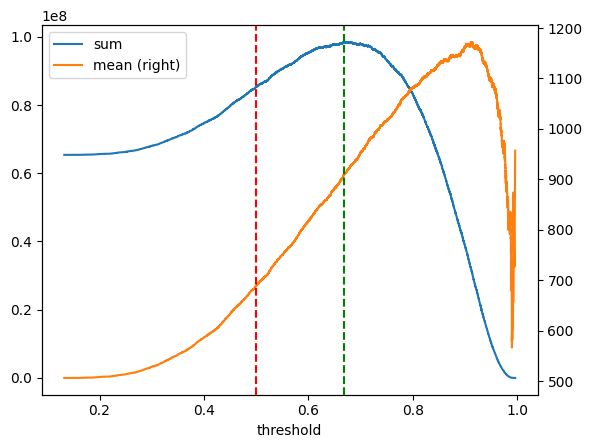

In [83]:
y_proba_test = lgb_model.predict_proba(X_test)[:, 0]
lgb_curve = build_curve(df_test.net_return, y_proba_test)
plot_curve(lgb_curve, 0.5)

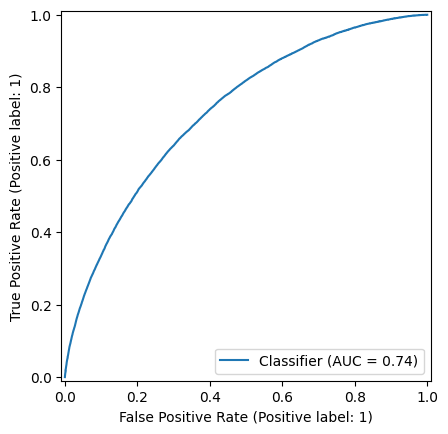

In [84]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, 1 - lgb_prediction)

Looks quite smooth, very good, but not a lot of signal.

In [85]:
y_proba_train = model.predict_proba(X_train)[:, 0]
print(f"Train Lift:     {lift_score(df_train['net_return'], y_proba_train):.4f}")
print(f"Test Lift:      {lift_score(df_test['net_return'], y_proba_test):.4f}")
print(f"Train ROC AUC:  {roc_auc_score(y_train, 1 - y_proba_train):.4f}")
print(f"Test ROC AUC:   {roc_auc_score(y_test, 1 - y_proba_test):.4f}")
print(f"Train Log Loss: {log_loss(y_train, 1 - y_proba_train):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, 1 - y_proba_test):.4f}")

Train Lift:     1.7390
Test Lift:      1.5063
Train ROC AUC:  0.7697
Test ROC AUC:   0.7358
Train Log Loss: 0.4247
Test Log Loss:  0.4434


The results show that classification models are worse than regression ones due to no knowledge of the actual returns. Only in overfitted regime does the model achieve optimal lift.

The lift already incorporates information on a good threshold so we don't need to concern ourselves with this tradeoff, but it's interesting to see the confusion matrix

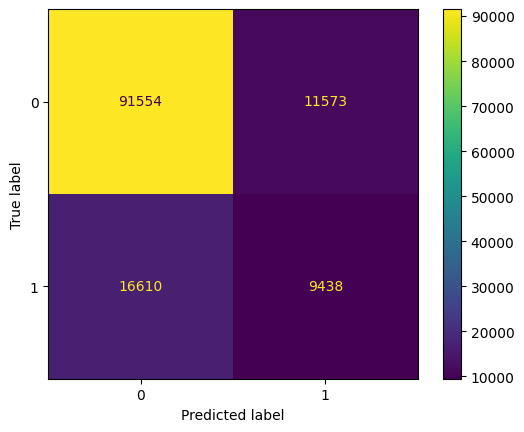

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.metrics import curve_threshold

threshold = curve_threshold(lgb_curve)
# no_default > threshold -> 1 is no default, should flip
y_pred = 1 - (y_proba_test >= threshold).astype(int)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [93]:
y_test.sum()

np.int64(26048)

Precision is poor: out of predicted 20k positives less than half are actual positives. Recall is even worse, out of 25k defaulter only 9k were correctly identified. Specificity is good. Threshold is such that we should have 0.67 and higher chances of a loan to not be a default to accept it, or label it as 0. So more loans are mislabeled under 1. And even with that we miss a lot of defaulters. But possibly, they are defaulter, prone not to take on big loans, so it doesn't harm the underline so much. 

## CART
We already see that even powerfull models struggle on classification task, but let's try to train CART model just for interpretability

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

categorical = X_train.select_dtypes(include='category').nunique()
one_hot_cols = categorical[categorical < 50].index.tolist()
target_cols = categorical[categorical >= 50].index.tolist()

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), one_hot_cols),
    ('target', TargetEncoder(), target_cols)
], remainder='passthrough', force_int_remainder_cols=False)

X_train_encoded = pd.DataFrame(preprocessor.fit_transform(X_train, y_train), columns=preprocessor.get_feature_names_out(), index=X_train.index)
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162575 entries, 1885073 to 681163
Columns: 112 entries, ohe__home_ownership_ANY to remainder__total_il_high_credit_limit
dtypes: object(112)
memory usage: 1002.3+ MB


In [27]:
from sklearn.tree import DecisionTreeClassifier

cart_model = DecisionTreeClassifier(random_state=42, max_depth=10)
cart_model.fit(X_train_encoded, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [28]:
path = cart_model.cost_complexity_pruning_path(X_train_encoded, y_train)
path

{'ccp_alphas': array([0.00000000e+00, 1.80971925e-08, 1.19466605e-06, 1.29023934e-06,
        1.42663229e-06, 1.43359927e-06, 1.43359927e-06, 1.43359927e-06,
        1.47455925e-06, 1.47455925e-06, 1.52917255e-06, 1.58376351e-06,
        1.59684889e-06, 1.60219862e-06, 1.66972150e-06, 1.69955461e-06,
        1.74650593e-06, 1.75918490e-06, 1.80223908e-06, 1.88751073e-06,
        1.90709343e-06, 1.97758812e-06, 2.00428841e-06, 2.02289261e-06,
        2.04560352e-06, 2.04799895e-06, 2.10230312e-06, 2.11952138e-06,
        2.21402924e-06, 2.31544352e-06, 2.32248751e-06, 2.32451804e-06,
        2.44510931e-06, 2.44602757e-06, 2.46318419e-06, 2.47648199e-06,
        2.47807873e-06, 2.52812114e-06, 2.52959953e-06, 2.55658780e-06,
        2.57666802e-06, 2.58047868e-06, 2.60050928e-06, 2.61118008e-06,
        2.62384807e-06, 2.65420664e-06, 2.66607195e-06, 2.72111173e-06,
        2.72747352e-06, 2.74629790e-06, 2.75251059e-06, 2.75557584e-06,
        2.76333363e-06, 2.77643049e-06, 2.77897704

<Axes: xlabel='ccp_alphas'>

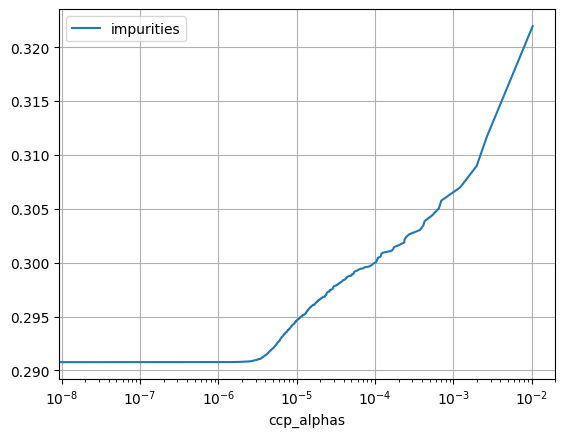

In [29]:
pd.DataFrame(path).plot(x='ccp_alphas', y='impurities', logx=True, grid=True)

<Axes: xlabel='ccp_alphas'>

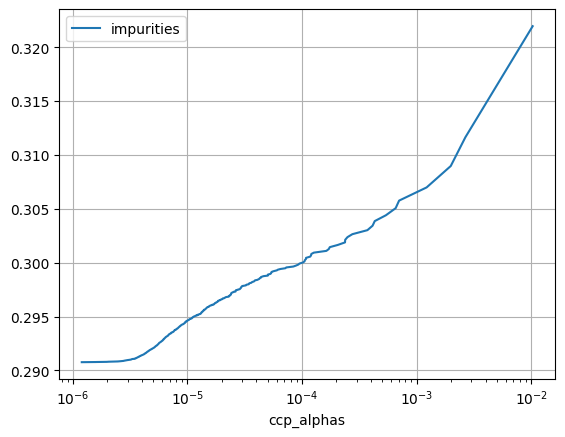

In [30]:
pd.DataFrame(path).query('ccp_alphas > 0.000001').plot(x='ccp_alphas', y='impurities', logx=True, grid=True)

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
records = []

ccp_alphas = np.logspace(-6, -2, num=20)
for alpha in ccp_alphas:
    print(alpha)
    model = DecisionTreeClassifier(ccp_alpha=alpha, max_depth=10)
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_fold_train, X_fold_val = X_train_encoded.iloc[train_idx], X_train_encoded.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

        def eval_metric(y_true, y_score):
            return ('lift', lift_score(val_return, 1 - y_score), True)

        model.fit(
            X_fold_train, 
            y_fold_train, 
        )

        pred_proba_train = model.predict_proba(X_fold_train)
        pred_proba_test = model.predict_proba(X_fold_val)

        lift_test = lift_score(val_return, pred_proba_test[:, 0])
        lift_train = lift_score(train_return, pred_proba_train[:, 0])
        log_loss_test = log_loss(y_fold_val, pred_proba_test[:, 1])
        log_loss_train = log_loss(y_fold_train, pred_proba_train[:, 1])
        roc_auc_test = roc_auc_score(y_fold_val, pred_proba_test[:, 1])
        roc_auc_train = roc_auc_score(y_fold_train, pred_proba_train[:, 1])

        depth = model.get_depth()

        records.append({
            'fold': fold_idx,
            'alpha': alpha,
            'train_lift': lift_train,
            'test_lift': lift_test,
            'train_log_loss': log_loss_train,
            'test_log_loss': log_loss_test,
            'train_roc_auc': roc_auc_train,
            'test_roc_auc': roc_auc_test,
            'depth': depth
        })

1e-06
1.6237767391887209e-06
2.6366508987303555e-06
4.281332398719396e-06
6.951927961775606e-06
1.1288378916846883e-05
1.8329807108324375e-05
2.9763514416313192e-05
4.8329302385717524e-05
7.847599703514606e-05
0.00012742749857031334
0.00020691380811147902
0.0003359818286283781
0.0005455594781168515
0.0008858667904100823
0.0014384498882876629
0.002335721469090121
0.003792690190732246
0.00615848211066026
0.01


In [13]:
results = pd.DataFrame(records)

<Axes: xlabel='alpha'>

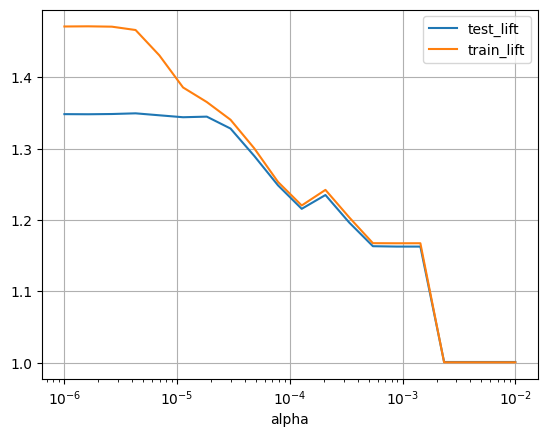

In [23]:
results.groupby('alpha').mean().plot(y=['test_lift', 'train_lift'], logx=True, grid=True)

<Axes: xlabel='alpha'>

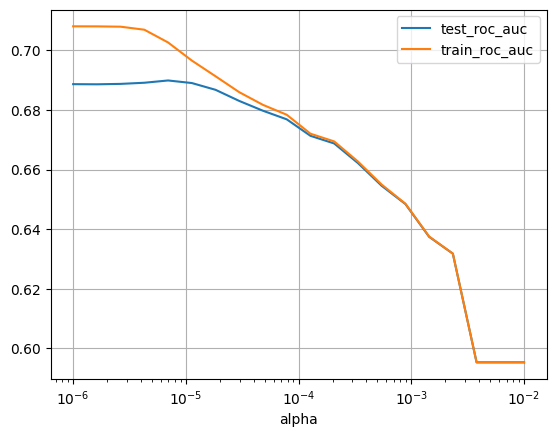

In [24]:
results.groupby('alpha').mean().plot(y=['test_roc_auc', 'train_roc_auc'], logx=True, grid=True)

<Axes: xlabel='alpha'>

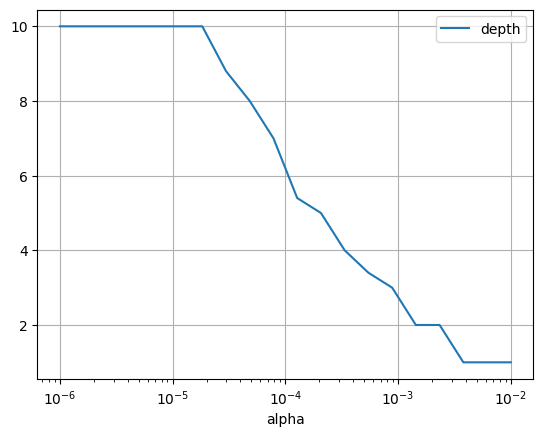

In [25]:
results.groupby('alpha').mean().plot(y='depth', logx=True, grid=True)

In [32]:
results.groupby('alpha').mean().sort_values('test_lift', ascending=False)

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc,depth
alpha,,,,,,,,
0.000004,2.0,1.466462,1.349651,0.456112,0.473864,0.706927,0.689125,10.0
0.000003,2.0,1.471161,1.348697,0.455471,0.479629,0.707942,0.688743,10.0
0.000001,2.0,1.471409,1.348513,0.455359,0.482454,0.708067,0.688651,10.0
0.000002,2.0,1.471647,1.348358,0.455386,0.482465,0.708050,0.688603,10.0
0.000007,2.0,1.430990,1.346903,0.458499,0.466513,0.702648,0.689891,10.0
0.000018,2.0,1.365503,1.345018,0.463926,0.465985,0.691303,0.686756,10.0
0.000011,2.0,1.385916,1.344174,0.461549,0.465201,0.696579,0.689029,10.0
0.000030,2.0,1.340671,1.328312,0.466109,0.467453,0.685953,0.683017,8.8
0.000048,2.0,1.300584,1.289915,0.467883,0.468716,0.681694,0.679725,8.0


Similarly to LightGBM, the model should be overtrained in order to have high test scores. Unlike with regression model, we need quite deep tree in order to capture the best lift. Let's select two models, one simple for prediction another simple one for interpretability

### Deep CART: model evaluation

In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
records = []

model = DecisionTreeClassifier(ccp_alpha=4e-6, max_depth=10)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(fold_idx)
    X_fold_train, X_fold_val = X_train_encoded.iloc[train_idx], X_train_encoded.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

    def eval_metric(y_true, y_score):
        return ('lift', lift_score(val_return, 1 - y_score), True)

    model.fit(
        X_fold_train, 
        y_fold_train, 
    )

    pred_proba_train = model.predict_proba(X_fold_train)
    pred_proba_test = model.predict_proba(X_fold_val)

    lift_test = lift_score(val_return, pred_proba_test[:, 0])
    lift_train = lift_score(train_return, pred_proba_train[:, 0])
    log_loss_test = log_loss(y_fold_val, pred_proba_test[:, 1])
    log_loss_train = log_loss(y_fold_train, pred_proba_train[:, 1])
    roc_auc_test = roc_auc_score(y_fold_val, pred_proba_test[:, 1])
    roc_auc_train = roc_auc_score(y_fold_train, pred_proba_train[:, 1])

    depth = model.get_depth()

    records.append({
        'fold': fold_idx,
        'train_lift': lift_train,
        'test_lift': lift_test,
        'train_log_loss': log_loss_train,
        'test_log_loss': log_loss_test,
        'train_roc_auc': roc_auc_train,
        'test_roc_auc': roc_auc_test,
        'depth': depth
    })

0
1
2
3
4


In [34]:
pd.DataFrame(records)

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc,depth
0,0,1.481190,1.348748,0.456256,0.472615,0.707075,0.689409,10
1,1,1.446519,1.332157,0.456243,0.474729,0.706954,0.688068,10
2,2,1.460982,1.358224,0.455820,0.475068,0.707232,0.689257,10
3,3,1.474410,1.351869,0.455774,0.473731,0.707104,0.690643,10
4,4,1.476854,1.354061,0.455797,0.478696,0.707410,0.687633,10


In [35]:
pd.DataFrame(records).agg(['mean', 'std'])

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc,depth
mean,2.000000,1.467991,1.349012,0.455978,0.474968,0.707155,0.689002,10.0
std,1.581139,0.014179,0.010033,0.000249,0.002293,0.000173,0.001191,0.0


That's quite low, better use regression trees

### Deep CART: final evaluation

In [36]:
model = DecisionTreeClassifier(ccp_alpha=4e-6, max_depth=10)
model.fit(X_train_encoded, y_train)
model.get_depth()

10

In [41]:
X_test_encoded = pd.DataFrame(preprocessor.transform(X_test), index=X_test.index, columns=preprocessor.get_feature_names_out())

Threshold: 0.6898
Lift: 1.3302 times
Net improvement: $8.698751e+07 - $6.539672e+07 = $2.159079e+07


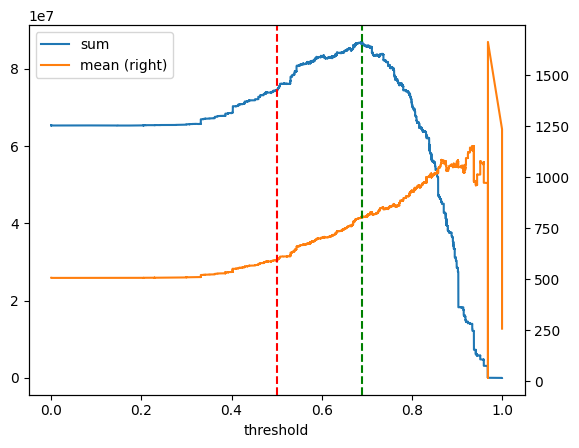

In [42]:
y_proba_test = model.predict_proba(X_test_encoded)[:, 0]
cart_curve = build_curve(df_test.net_return, y_proba_test)
plot_curve(cart_curve, 0.5)

Threshold is somewhat higher than with LightGBM model, return is poorer (1.33 against 1.506). Curve is quite erradic since predicted probability of default is not necessarily a good measure of monetary return

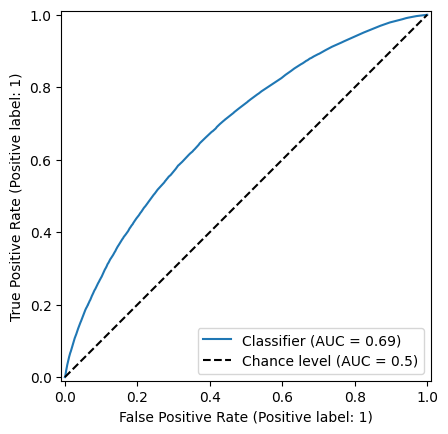

In [45]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, 1 - y_proba_test, plot_chance_level=True)

Smooth, simply worse than LightGBM

In [46]:
y_proba_train = model.predict_proba(X_train_encoded)[:, 0]
print(f"Train Lift:     {lift_score(df_train['net_return'], y_proba_train):.4f}")
print(f"Test Lift:      {lift_score(df_test['net_return'], y_proba_test):.4f}")
print(f"Train ROC AUC:  {roc_auc_score(y_train, 1 - y_proba_train):.4f}")
print(f"Test ROC AUC:   {roc_auc_score(y_test, 1 - y_proba_test):.4f}")
print(f"Train Log Loss: {log_loss(y_train, 1 - y_proba_train):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, 1 - y_proba_test):.4f}")

Train Lift:     1.4588
Test Lift:      1.3302
Train ROC AUC:  0.7047
Test ROC AUC:   0.6892
Train Log Loss: 0.4574
Test Log Loss:  0.4701


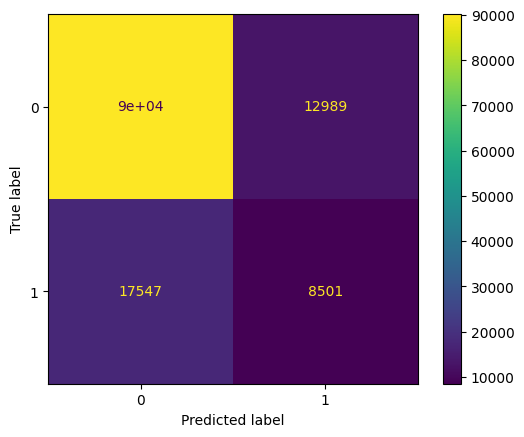

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.metrics import curve_threshold

threshold = curve_threshold(cart_curve)
# no_default > threshold -> 1 is no default, should flip
y_pred = 1 - (y_proba_test >= threshold).astype(int)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

Situation is similar to LightGBM

### Shallow CART: model evaluation

In [54]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
records = []

model = DecisionTreeClassifier(ccp_alpha=8e-5, max_depth=10)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(fold_idx)
    X_fold_train, X_fold_val = X_train_encoded.iloc[train_idx], X_train_encoded.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    train_return, val_return = df.loc[X_fold_train.index, 'net_return'], df.loc[X_fold_val.index, 'net_return']

    def eval_metric(y_true, y_score):
        return ('lift', lift_score(val_return, 1 - y_score), True)

    model.fit(
        X_fold_train, 
        y_fold_train, 
    )

    pred_proba_train = model.predict_proba(X_fold_train)
    pred_proba_test = model.predict_proba(X_fold_val)

    lift_test = lift_score(val_return, pred_proba_test[:, 0])
    lift_train = lift_score(train_return, pred_proba_train[:, 0])
    log_loss_test = log_loss(y_fold_val, pred_proba_test[:, 1])
    log_loss_train = log_loss(y_fold_train, pred_proba_train[:, 1])
    roc_auc_test = roc_auc_score(y_fold_val, pred_proba_test[:, 1])
    roc_auc_train = roc_auc_score(y_fold_train, pred_proba_train[:, 1])

    depth = model.get_depth()

    records.append({
        'fold': fold_idx,
        'train_lift': lift_train,
        'test_lift': lift_test,
        'train_log_loss': log_loss_train,
        'test_log_loss': log_loss_test,
        'train_roc_auc': roc_auc_train,
        'test_roc_auc': roc_auc_test,
        'depth': depth
    })

0
1
2
3
4


In [55]:
pd.DataFrame(records)

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc,depth
0,0,1.226946,1.210386,0.469483,0.469218,0.677643,0.675680,7
1,1,1.252254,1.259749,0.469402,0.469388,0.678101,0.676245,7
2,2,1.284125,1.295596,0.469005,0.470301,0.678392,0.677307,7
3,3,1.244360,1.235833,0.468943,0.469788,0.678622,0.679101,7
4,4,1.260813,1.244684,0.469306,0.470464,0.677945,0.674917,7


In [56]:
pd.DataFrame(records).agg(['mean', 'std'])

,fold,train_lift,test_lift,train_log_loss,test_log_loss,train_roc_auc,test_roc_auc,depth
mean,2.000000,1.253700,1.249250,0.469228,0.469832,0.678140,0.676650,7.0
std,1.581139,0.021103,0.031502,0.000241,0.000547,0.000382,0.001624,0.0


The performance is even worse

### Shallow CART: final evaluation

In [57]:
model = DecisionTreeClassifier(ccp_alpha=8e-5, max_depth=10)
model.fit(X_train_encoded, y_train)
model.get_depth()

7

Threshold: 0.6645
Lift: 1.2160 times
Net improvement: $7.952269e+07 - $6.539672e+07 = $1.412596e+07


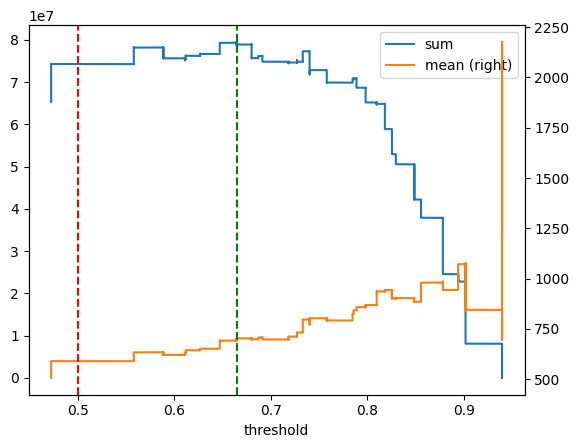

In [58]:
y_proba_test = model.predict_proba(X_test_encoded)[:, 0]
cart_curve = build_curve(df_test.net_return, y_proba_test)
plot_curve(cart_curve, 0.5)

The optimal threshold is similar to LightGBM, but honestly it seems like it simply comes from random factor and the model may be not very usefull

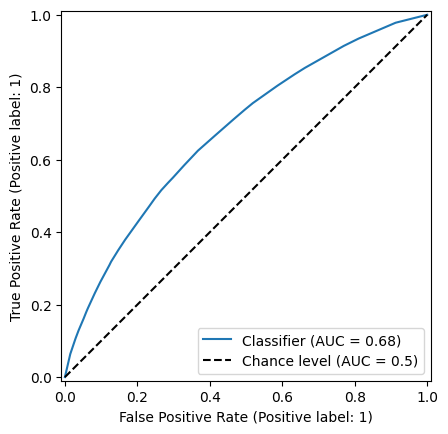

In [62]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, 1 - y_proba_test, plot_chance_level=True)

In [63]:
y_proba_train = model.predict_proba(X_train_encoded)[:, 0]
print(f"Train Lift:     {lift_score(df_train['net_return'], y_proba_train):.4f}")
print(f"Test Lift:      {lift_score(df_test['net_return'], y_proba_test):.4f}")
print(f"Train ROC AUC:  {roc_auc_score(y_train, 1 - y_proba_train):.4f}")
print(f"Test ROC AUC:   {roc_auc_score(y_test, 1 - y_proba_test):.4f}")
print(f"Train Log Loss: {log_loss(y_train, 1 - y_proba_train):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, 1 - y_proba_test):.4f}")

Train Lift:     1.2553
Test Lift:      1.2160
Train ROC AUC:  0.6782
Test ROC AUC:   0.6764
Train Log Loss: 0.4693
Test Log Loss:  0.4702


Not good

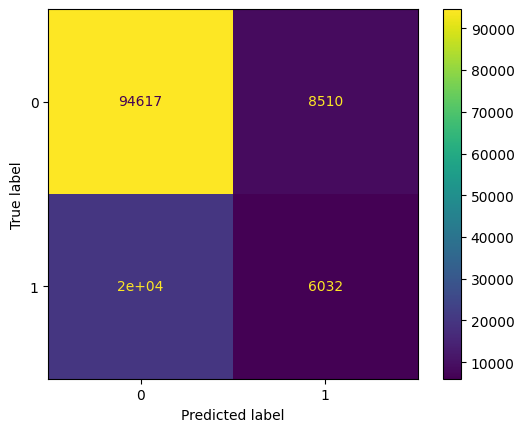

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.metrics import curve_threshold

threshold = curve_threshold(cart_curve)
# no_default > threshold -> 1 is no default, should flip
y_pred = 1 - (y_proba_test >= threshold).astype(int)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

This model has fewer False positives than LightGBM, but more False negatives, so it has higher precision and worse recall, so defaulters are even more underpredicted.

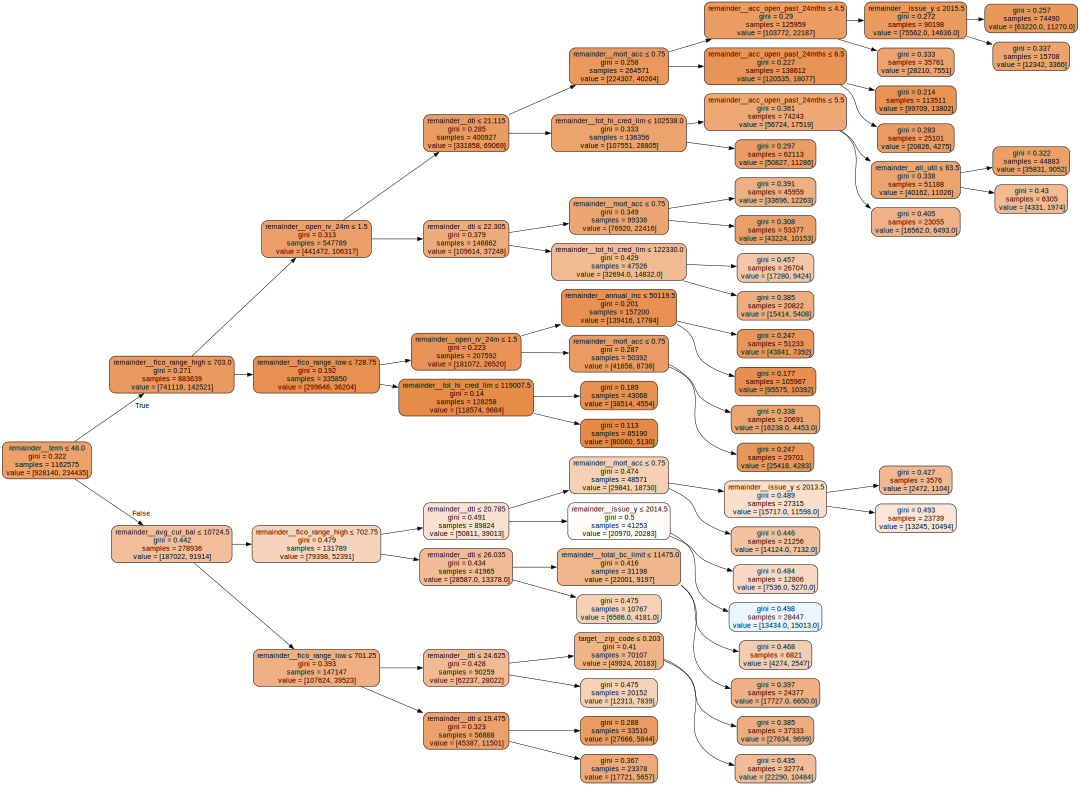

In [65]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(model,
                           max_depth=8,
                           feature_names=X_train_encoded.columns,
                           filled=True,
                           rounded=True,
                           special_characters=True)

dot_data = dot_data.replace('digraph Tree {', 'digraph Tree {\nrankdir=LR;\nsize="15!"; ratio=compress;')
graph = graphviz.Source(dot_data)
graph

Classification tree has very understandable splits: good fico, high credit limit, high current balance, low dti lead to smaller chance of default. Term and issue year affect things, but not as much as with regression tree.

### Other models
We've already seen the lack of signal in classification formulation of a task, so there is little use in trying other models. KNN, SVM are very slow at large datasets. Logistic regression can be nice and interpretable, but it probably won't be better than LightGBM. 